In [17]:
import scanpy as sc

In [18]:
adata = sc.read_h5ad("DICTY_snapTotal.h5ad")

In [19]:
print(adata.X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 28045 stored elements and shape (5, 13376)>
  Coords	Values
  (0, 3)	1.0
  (0, 24)	1.0
  (0, 34)	2.0
  (0, 36)	1.0
  (0, 52)	1.0
  (0, 59)	1.0
  (0, 72)	16.0
  (0, 76)	14.0
  (0, 79)	93.0
  (0, 80)	29.0
  (0, 82)	118.0
  (0, 83)	269.0
  (0, 84)	1.0
  (0, 85)	203.0
  (0, 86)	7.0
  (0, 87)	59.0
  (0, 88)	7.0
  (0, 89)	2.0
  (0, 90)	7.0
  (0, 92)	518.0
  (0, 93)	29.0
  (0, 94)	43.0
  (0, 95)	15.0
  (0, 96)	5.0
  (0, 97)	4.0
  :	:
  (4, 13283)	39.0
  (4, 13284)	4.0
  (4, 13286)	2.0
  (4, 13289)	1.0
  (4, 13296)	3.0
  (4, 13297)	1.0
  (4, 13299)	1.0
  (4, 13304)	1.0
  (4, 13305)	4.0
  (4, 13309)	1.0
  (4, 13310)	1.0
  (4, 13311)	4.0
  (4, 13320)	18.0
  (4, 13322)	5.0
  (4, 13328)	1.0
  (4, 13330)	4.0
  (4, 13331)	2.0
  (4, 13333)	4.0
  (4, 13335)	3.0
  (4, 13345)	2.0
  (4, 13352)	1.0
  (4, 13366)	16.0
  (4, 13367)	1.0
  (4, 13372)	21.0
  (4, 13375)	1.0


In [20]:
adata

AnnData object with n_obs × n_vars = 5 × 13376
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_unspliced', 'nFeature_unspliced', 'nCount_spliced', 'nFeature_spliced'
    var: 'features', 'spliced_features', 'unspliced_features'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'spliced', 'unspliced'

In [ ]:
# Filter out these ones 
# chrR	biox	rRNA	79600	80283	0	+	.	gene_id "DDB_G0295655"; transcript_id "DDB_G0295655"; gene_name "5S_rRNA-2";
# chrR	biox	exon	79600	80283	0	+	0	gene_id "DDB_G0295655"; transcript_id "DDB_G0295655"; gene_name "5S_rRNA-2";
# chrR	biox	rRNA	73642	73803	0	+	.	gene_id "DDB_G0295651"; transcript_id "DDB_G0295651"; gene_name "5.8S_rRNA-2";
# chrR	biox	exon	73642	73803	0	+	0	gene_id "DDB_G0295651"; transcript_id "DDB_G0295651"; gene_name "5.8S_rRNA-2";
# chrR	biox	rRNA	74379	77619	0	+	.	gene_id "DDB_G0295653"; transcript_id "DDB_G0295653"; gene_name "26S_rRNA-2";
# chrR	biox	exon	74379	77619	0	+	0	gene_id "DDB_G0295653"; transcript_id "DDB_G0295653"; gene_name "26S_rRNA-2";
# chrR	biox	rRNA	7570	10810	0	-	.	gene_id "DDB_G0295643"; transcript_id "DDB_G0295643"; gene_name "26S_rRNA-1";
# chrR	biox	exon	7570	10810	0	-	0	gene_id "DDB_G0295643"; transcript_id "DDB_G0295643"; gene_name "26S_rRNA-1";
# chrR	biox	rRNA	4906	5589	0	-	.	gene_id "DDB_G0295641"; transcript_id "DDB_G0295641"; gene_name "5S_rRNA-1";
# chrR	biox	exon	4906	5589	0	-	0	gene_id "DDB_G0295641"; transcript_id "DDB_G0295641"; gene_name "5S_rRNA-1";
# chrR	biox	rRNA	11608	13748	0	-	.	gene_id "DDB_G0295647"; transcript_id "DDB_G0295647"; gene_name "17S_rRNA-1";
# chrR	biox	exon	11608	13748	0	-	0	gene_id "DDB_G0295647"; transcript_id "DDB_G0295647"; gene_name "17S_rRNA-1";
# chrR	biox	rRNA	11386	11547	0	-	.	gene_id "DDB_G0295645"; transcript_id "DDB_G0295645"; gene_name "5.8S_rRNA-1";
# chrR	biox	exon	11386	11547	0	-	0	gene_id "DDB_G0295645"; transcript_id "DDB_G0295645"; gene_name "5.8S_rRNA-1";
# chrR	biox	rRNA	71441	73311	0	+	.	gene_id "DDB_G0295649"; transcript_id "DDB_G0295649"; gene_name "17S_rRNA-2";
# chrR	biox	exon	71441	73311	0	+	0	gene_id "DDB_G0295649"; transcript_id "DDB_G0295649"; gene_name "17S_rRNA-2";


In [26]:
remove = ["DDB-G0295649","DDB-G0295655","DDB-G0295651","DDB-G0295653","DDB-G0295643","DDB-G0295641","DDB-G0295647","DDB-G0295645"]
mask = ~adata.var["features"].isin(remove)
adata = adata[:, mask].copy()


In [35]:
import scvelo as scv
scv.pp.normalize_per_cell(adata, enforce=True)
scv.pp.filter_genes_dispersion(adata, n_top_genes=2000)
scv.pp.log1p(adata)
scv.pp.moments(adata, n_pcs=2, n_neighbors=20)

Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
computing neighbors


/var/folders/b0/d34rvffj6l18k2sl5mb16w440000gn/T/ipykernel_78712/1824105468.py:4: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  scv.pp.log1p(adata)
/var/folders/b0/d34rvffj6l18k2sl5mb16w440000gn/T/ipykernel_78712/1824105468.py:5: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=2, n_neighbors=20)
/opt/anaconda3/envs/total_scRNA_310/lib/python3.10/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [36]:
scv.tl.recover_dynamics(adata, fit_basal_transcription=True, n_jobs=12)
scv.tl.velocity(adata, mode='dynamical')
scv.tl.velocity_graph(adata)

recovering dynamics (using 12/12 cores)


  0%|          | 0/64 [00:00<?, ?gene/s]

    finished (0:00:03) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/12 cores)


  0%|          | 0/5 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [41]:
sc.pp.neighbors(adata)
sc.tl.pca(adata)

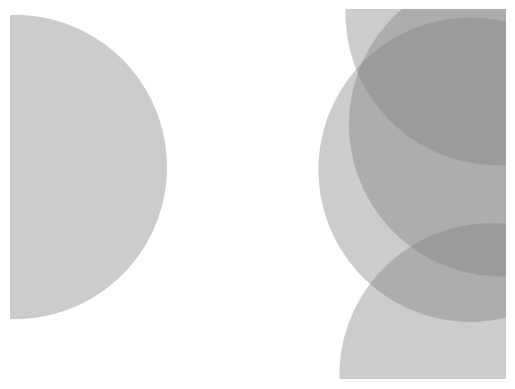

In [46]:
scv.pl.velocity_embedding_stream(adata, basis='pca', alpha=0.4, n_neighbors=3)

In [53]:
adata.obsm["velocity_pca"]

array([[-0.62742377, -0.03207655,  0.43392687, -0.15346897],
       [-0.19002248, -0.093914  , -0.06246253, -0.06990061],
       [-0.71257124,  0.04176506,  0.59694658, -0.05341703],
       [ 0.00152314,  0.01232088,  0.02490855,  0.00668902],
       [ 0.49003473, -0.00283394, -0.47512484,  0.03069201]])

In [49]:
adata

AnnData object with n_obs × n_vars = 5 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_unspliced', 'nFeature_unspliced', 'nCount_spliced', 'nFeature_spliced', 'n_counts', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'velocity_self_transition'
    var: 'features', 'spliced_features', 'unspliced_features', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes'
    uns: 'log1p', 'neighbors', 'recover_dynamics', 'velocity_params', 'velocity_graph', 'velocity_graph_neg', 'pca'
    obsm: 'X_pca', 'velocity_pca'
    varm: 'PCs', 'loss'
    layers: 'spliced', 'unspliced', 'Ms', 'Mu', 'fit_t', 'fit_tau', 'fit_tau_', 'velocity', 'velocity_u'
    obsp: 'distances', 'connectivities'